<a href="https://colab.research.google.com/github/Carmen10-171/01MIAR_ABR26/blob/main/01MIAR_Exam_01_B_Solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen Primera Convocatoria Franja Tarde

In [ ]:
# Your imports HERE !!!!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 01 - Transformar edad (1 pto)
El dataframe animales tiene los valores de edad (age) cómo números flotantes. Programa una función `convertir_mes()` para convertir los valores de años a meses y aplícala a la columna **age**. Los meses deben ser valores enteros aproximados hacia abajo.

In [ ]:
# Your code HERE
def convertir_mes(df):
    my_funcion = lambda x : int(np.floor(x * 12))
    df["age"] = df["age"].apply(my_funcion)
    return df

In [ ]:
# Test Use Case
pets = pd.DataFrame({'animal': ['cat', 'cat', 'snake', 'dog', 'dog', 'cat', 'snake', 'cat', 'dog', 'dog'],
                     'age': [2.56, 3.43, 0.75, 3.15, 5.12, 2.89, 4.15, 0.62, 7.10, 3.98],
                     'visits': [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],
                     'priority': ['yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']})

expected_output = pd.DataFrame({'animal': ['cat', 'cat', 'snake', 'dog', 'dog', 'cat', 'snake', 'cat', 'dog', 'dog'],
                                'age': [30, 41, 9, 37, 61, 34, 49, 7, 85, 47],
                                'visits': [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],
                                'priority': ['yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']})
display(expected_output)

output = convertir_mes(pets)   # This calls your function convertir_mes
display(output)

assert(expected_output.equals(output))   # This fails is the data is wrong

,animal,age,visits,priority
0,cat,30,1,yes
1,cat,41,3,yes
2,snake,9,2,no
3,dog,37,3,yes
4,dog,61,2,no
5,cat,34,3,no
6,snake,49,1,no
7,cat,7,1,yes
8,dog,85,2,no
9,dog,47,1,no


,animal,age,visits,priority
0,cat,30,1,yes
1,cat,41,3,yes
2,snake,9,2,no
3,dog,37,3,yes
4,dog,61,2,no
5,cat,34,3,no
6,snake,49,1,no
7,cat,7,1,yes
8,dog,85,2,no
9,dog,47,1,no


## 02 - Agrupar por prioridad (1 pto)
Cogiendo los datos de salida del ejercicio anterior, escribe una función que obtenga el promedio de edad y de visitas de las mascotas con prioridad.

In [ ]:
# Your code HERE !!!!
def mean_age_visits_with_priority(df):
    prioridad = df.groupby("priority").mean(numeric_only=True)
    edad_mean = prioridad.loc["yes","age"]
    visitas_mean = prioridad.loc["yes","visits"]
    return edad_mean, visitas_mean

In [ ]:
# Test Use Case
pets = pd.DataFrame({'animal': ['cat', 'cat', 'snake', 'dog', 'dog', 'cat', 'snake', 'cat', 'dog', 'dog'],
                                'age': [30, 41, 9, 37, 61, 34, 49, 7, 85, 47],
                                'visits': [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],
                                'priority': ['yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']})
expected_output = (28.75, 2.0)
print(f"Mean age = {expected_output[0]}, Mean visits = {expected_output[1]}")

output = mean_age_visits_with_priority(pets)        # This calls your function mean_age_visits_with_priority
print(f"Mean age = {output[0]}, Mean visits = {output[1]}")

assert(expected_output == output)  # This fails is the data is wrong

Mean age = 28.75, Mean visits = 2.0
Mean age = 28.75, Mean visits = 2.0


## 03 - Desanidador con generador (2 pts)
La función `desanidador()` que mostramos a continuación es recursiva y convierte una lista anidada en una lista desanidada (todos sus elementos uno al lado del otro). ¿Cómo puedes modificar esta función para convertirla en un **generador**?

**Pista:** En un generador puedes aprovechar la recursividad a través de un pipeline

In [ ]:
# You need to change HERE !!!!
def desanidador(lista):
    # olista = []
    for objeto in lista:
        if type(objeto) is int:
            yield objeto
            # olista.append(objeto)
        else:
            pipeline = (o for o in desanidador(objeto))
            for o in pipeline:
                yield o
    #         olista.extend(desanidador(objeto))
    # return olista

In [ ]:
# Test Use Case
lanidada = [1,2,3,[4,5,[[6,7,8,9],8,[7,6,5],4],3,2,1,2,3,[4,[5,6],7,[8,9,8,[7,6,5],4],3,2],1,2,[3,4,5],6],7,8,9]
expected_output = [1,2,3,4,5,6,7,8,9,8,7,6,5,4,3,2,1,2,3,4,5,6,7,8,9,8,7,6,5,4,3,2,1,2,3,4,5,6,7,8,9]
print(expected_output)

gen = desanidador(lanidada)   # This calls your generator function called desanidador
output = [x for x in gen]
print(output)

assert(output == expected_output)   # This fails is the data is wrong

[1, 2, 3, 4, 5, 6, 7, 8, 9, 8, 7, 6, 5, 4, 3, 2, 1, 2, 3, 4, 5, 6, 7, 8, 9, 8, 7, 6, 5, 4, 3, 2, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 8, 7, 6, 5, 4, 3, 2, 1, 2, 3, 4, 5, 6, 7, 8, 9, 8, 7, 6, 5, 4, 3, 2, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## 04 - Preparación de datos (6 pts)

Junto con el examen se ha añadido un fichero llamado `exams.csv` donde se encuentra el rendimiento de estudiantes en matemáticas. El dataset contiene 8 columnas.
 - **Gender:** El género del estudiante.
 - **Race/ethnicity:** Raza o etnia del estudiante.
 - **Parental level of education:** Nivel educativo más alto alcanzado por los padres/tutores.
 - **Lunch:** Si el estudiante recibe algún tipo de pensión para comida.
 - **Test preparation course:** Si el estudiante recibió algùn curso de preparación.
 - **Math score:** Calificación del estudiante en matemáticas.
 - **Reading score:** Calificación del estudiante en pruebas de lectura.
 - **Writing score:** Calificación del estudiante en pruebas de escritura.

Tu tarea es:
1. (0.25 pts) Cargar el contenido en un dataframe
2. (0.75 pts) Identificar cuales de las columnas son categóricas y, de estas columnas, identificar cuales son los valores posibles.
3. (1.00 pto) Transformar las calificaciones en variables categóricas:
     - 0 a 49: **Not Aproved**
     - 50 a 70: **Aproved**
     - 71 a 90: **Very Good**
     - 91 a 100: **Excellent**
4. (0.50 pts) Identificar cuantos estudiantes están suspendidos **Not Aproved** en las tres calificaciones, guardarlos en un dataframe llamado **profileA**.
5. (0.50 pts) Identificar cuantos estudiantes han tenido un **Excelent** en las tres calificaciones, guardarlos en un dataframe llamado **profileB**.
6. (0.50 pts) Guardar los demás estudiantes en un dataframe llamado **control**.
7. (1.50 pts) Crear gráficos de pastel para cada dataframe (**profileA**, **profileB** y **control**) donde se vea la distribución de los estudiantes según las columnas **Race/ethnicity** y **Parental level of education**.
8. (1.00 pto) Guardar cada dataframe en su respectivo fichero `.csv` (**ProfileA.csv**, **ProfileB.csv**, **Control.csv**)

In [ ]:
# 1. Cargar el contenido en un dataframe.

df = pd.read_csv("exams.csv", sep=',', engine='python')
display(df.head(4))

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87
2,female,group D,some college,free/reduced,none,57,76,77
3,male,group B,some college,free/reduced,none,70,70,63


In [ ]:
# 2. Identificar cuales de las columnas son categóricas y, de estas columnas, identificar cuales son los valores posibles

df.info()
print()
for column in df:
    if df[column].dtype == 'object':
        df[column] = df[column].astype('category')
        print('La columna {} es categórica y tiene {} posibles valores:'.format(column, len(df[column].unique())))
        print(df[column].unique())
        print()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               10

In [ ]:
# 3. Transformar las calificaciones en variables categóricas:
#        0 a 49: Not Aproved
#        50 a 70: Aproved
#        71 a 90: Very Good
#        91 a 100: Excellent

bins = [0,50,71,91,101]
etiquetas = ["Not Aproved","Aproved","Very Good","Excellent"]

df["math score"] = pd.cut(df["math score"],bins,labels=etiquetas)
df["reading score"] = pd.cut(df["reading score"],bins,labels=etiquetas)
df["writing score"] = pd.cut(df["writing score"],bins,labels=etiquetas)

display(df.head(4))

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,Aproved,Aproved,Very Good
1,male,group D,associate's degree,standard,none,Excellent,Excellent,Very Good
2,female,group D,some college,free/reduced,none,Aproved,Very Good,Very Good
3,male,group B,some college,free/reduced,none,Aproved,Aproved,Aproved


In [ ]:
# 4. Identificar cuantos estudiantes están suspendidos "Not Aproved" en las tres calificaciones, guardarlos en un dataframe llamado "profileA".

maskA = (df["math score"] == "Not Aproved") * (df["reading score"] == "Not Aproved") * (df["writing score"] == "Not Aproved")
profileA = df[maskA]
display(profileA.head(4))

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
16,female,group C,some college,free/reduced,none,Not Aproved,Not Aproved,Not Aproved
33,female,group D,master's degree,free/reduced,none,Not Aproved,Not Aproved,Not Aproved
40,male,group C,associate's degree,free/reduced,completed,Not Aproved,Not Aproved,Not Aproved
65,female,group B,associate's degree,free/reduced,none,Not Aproved,Not Aproved,Not Aproved


In [ ]:
# 5. Identificar cuantos estudiantes han tenido un "Excelent" en las tres calificaciones, guardarlos en un dataframe llamado "profileB".

maskB = (df["math score"] == "Excellent") * (df["reading score"] == "Excellent") * (df["writing score"] == "Excellent")
profileB = df[maskB]
display(profileB.head(4))

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
115,female,group E,bachelor's degree,standard,none,Excellent,Excellent,Excellent
185,female,group D,master's degree,free/reduced,none,Excellent,Excellent,Excellent
292,female,group E,associate's degree,standard,none,Excellent,Excellent,Excellent
312,female,group D,high school,standard,completed,Excellent,Excellent,Excellent


In [ ]:
# 6. Guardar los demás estudiantes en un dataframe llamado "control".

maskC = ~((maskA) + (maskB))
control = df[maskC]
display(control.head(4))

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,Aproved,Aproved,Very Good
1,male,group D,associate's degree,standard,none,Excellent,Excellent,Very Good
2,female,group D,some college,free/reduced,none,Aproved,Very Good,Very Good
3,male,group B,some college,free/reduced,none,Aproved,Aproved,Aproved


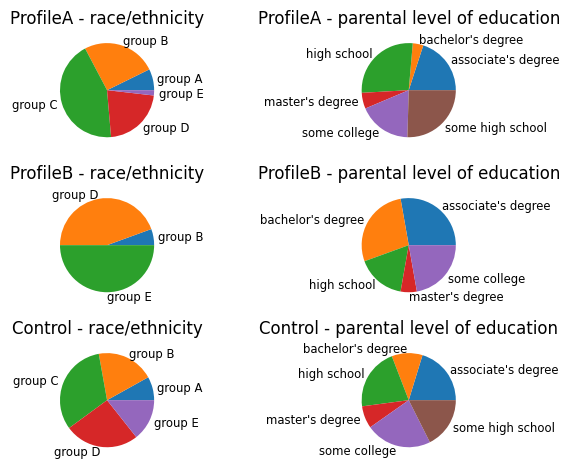

In [ ]:
# 7. Crear gráficos de pastel para cada dataframe (profileA, profileB y control) donde se vea la distribución de los estudiantes según las columnas "race/ethnicity" y "parental level of education".

dfs = [profileA, profileB, control]
df_names = ["ProfileA", "ProfileB", "Control"]
cols = ["race/ethnicity", "parental level of education"]

fig, axes = plt.subplots(len(dfs), len(cols))

for fi,frame in enumerate(dfs):
    for ci,col in enumerate(cols):
        pie_data = frame[col].value_counts().sort_index()
        axes[fi][ci].pie(pie_data, labels=pie_data.index, textprops={'size': 'smaller'},)
        axes[fi][ci].set_title("{} - {}".format(df_names[fi], col))

fig.tight_layout()

In [ ]:
# 8. Guardar cada dataframe en su respectivo fichero .csv (ProfileA.csv, ProfileB.csv, Control.csv)

for fi,frame in enumerate(dfs):
    ruta_output = "{}.csv".format(df_names[fi])
    frame.to_csv(ruta_output, sep=',')